# Mass balance figures

This notebook generates figures describing the mass balance measurements and modelling approach for the polythermal Swiss glaciers paper.

**Figures produced:**
1. Mosaic of GLAMOS modelled winter balance distributions (2024/25) for all 6 glaciers
2. Annual firn area time series (1970–2026) for all 6 glaciers
3. *(placeholder)* Firn thickness snapshot maps


In [1]:
%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi']  = 200
mpl.rcParams['font.family'] = 'Arial'

import os
import sys       
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from pathlib import Path

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

output_dir = project_root + '/products/figures/mass_balance_figures/'
os.makedirs(output_dir, exist_ok=True)

---
## Figure 1 — GLAMOS modelled winter balance distributions (2024/25)

Mosaic of the six GLAMOS winter balance map screenshots, one per glacier.
Adjust the `glamos_files` mapping below if the glacier assignment is wrong.

In [2]:
glamos_dir = project_root + '/data/glamos/wb_figures/'

# --- assign screenshots to glaciers (adjust order if needed) ---
# files are sorted by timestamp (alphabetical = chronological)
all_files = sorted(Path(glamos_dir).glob('*.png'))
print('Files found:')
for i, f in enumerate(all_files):
    print(f'  [{i}] {f.name}')

Files found:
  [0] 01_Alphubel.png
  [1] 02_Chessjen.png
  [2] 03_Hohsaas.png
  [3] 04_SexRouge.png
  [4] 05_Tortin.png
  [5] 06_Corvatsch.png


Saved: /Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/polythermal_swiss_glaciers/products/figures/mass_balance_figures/glamos_winter_balance_mosaic.pdf


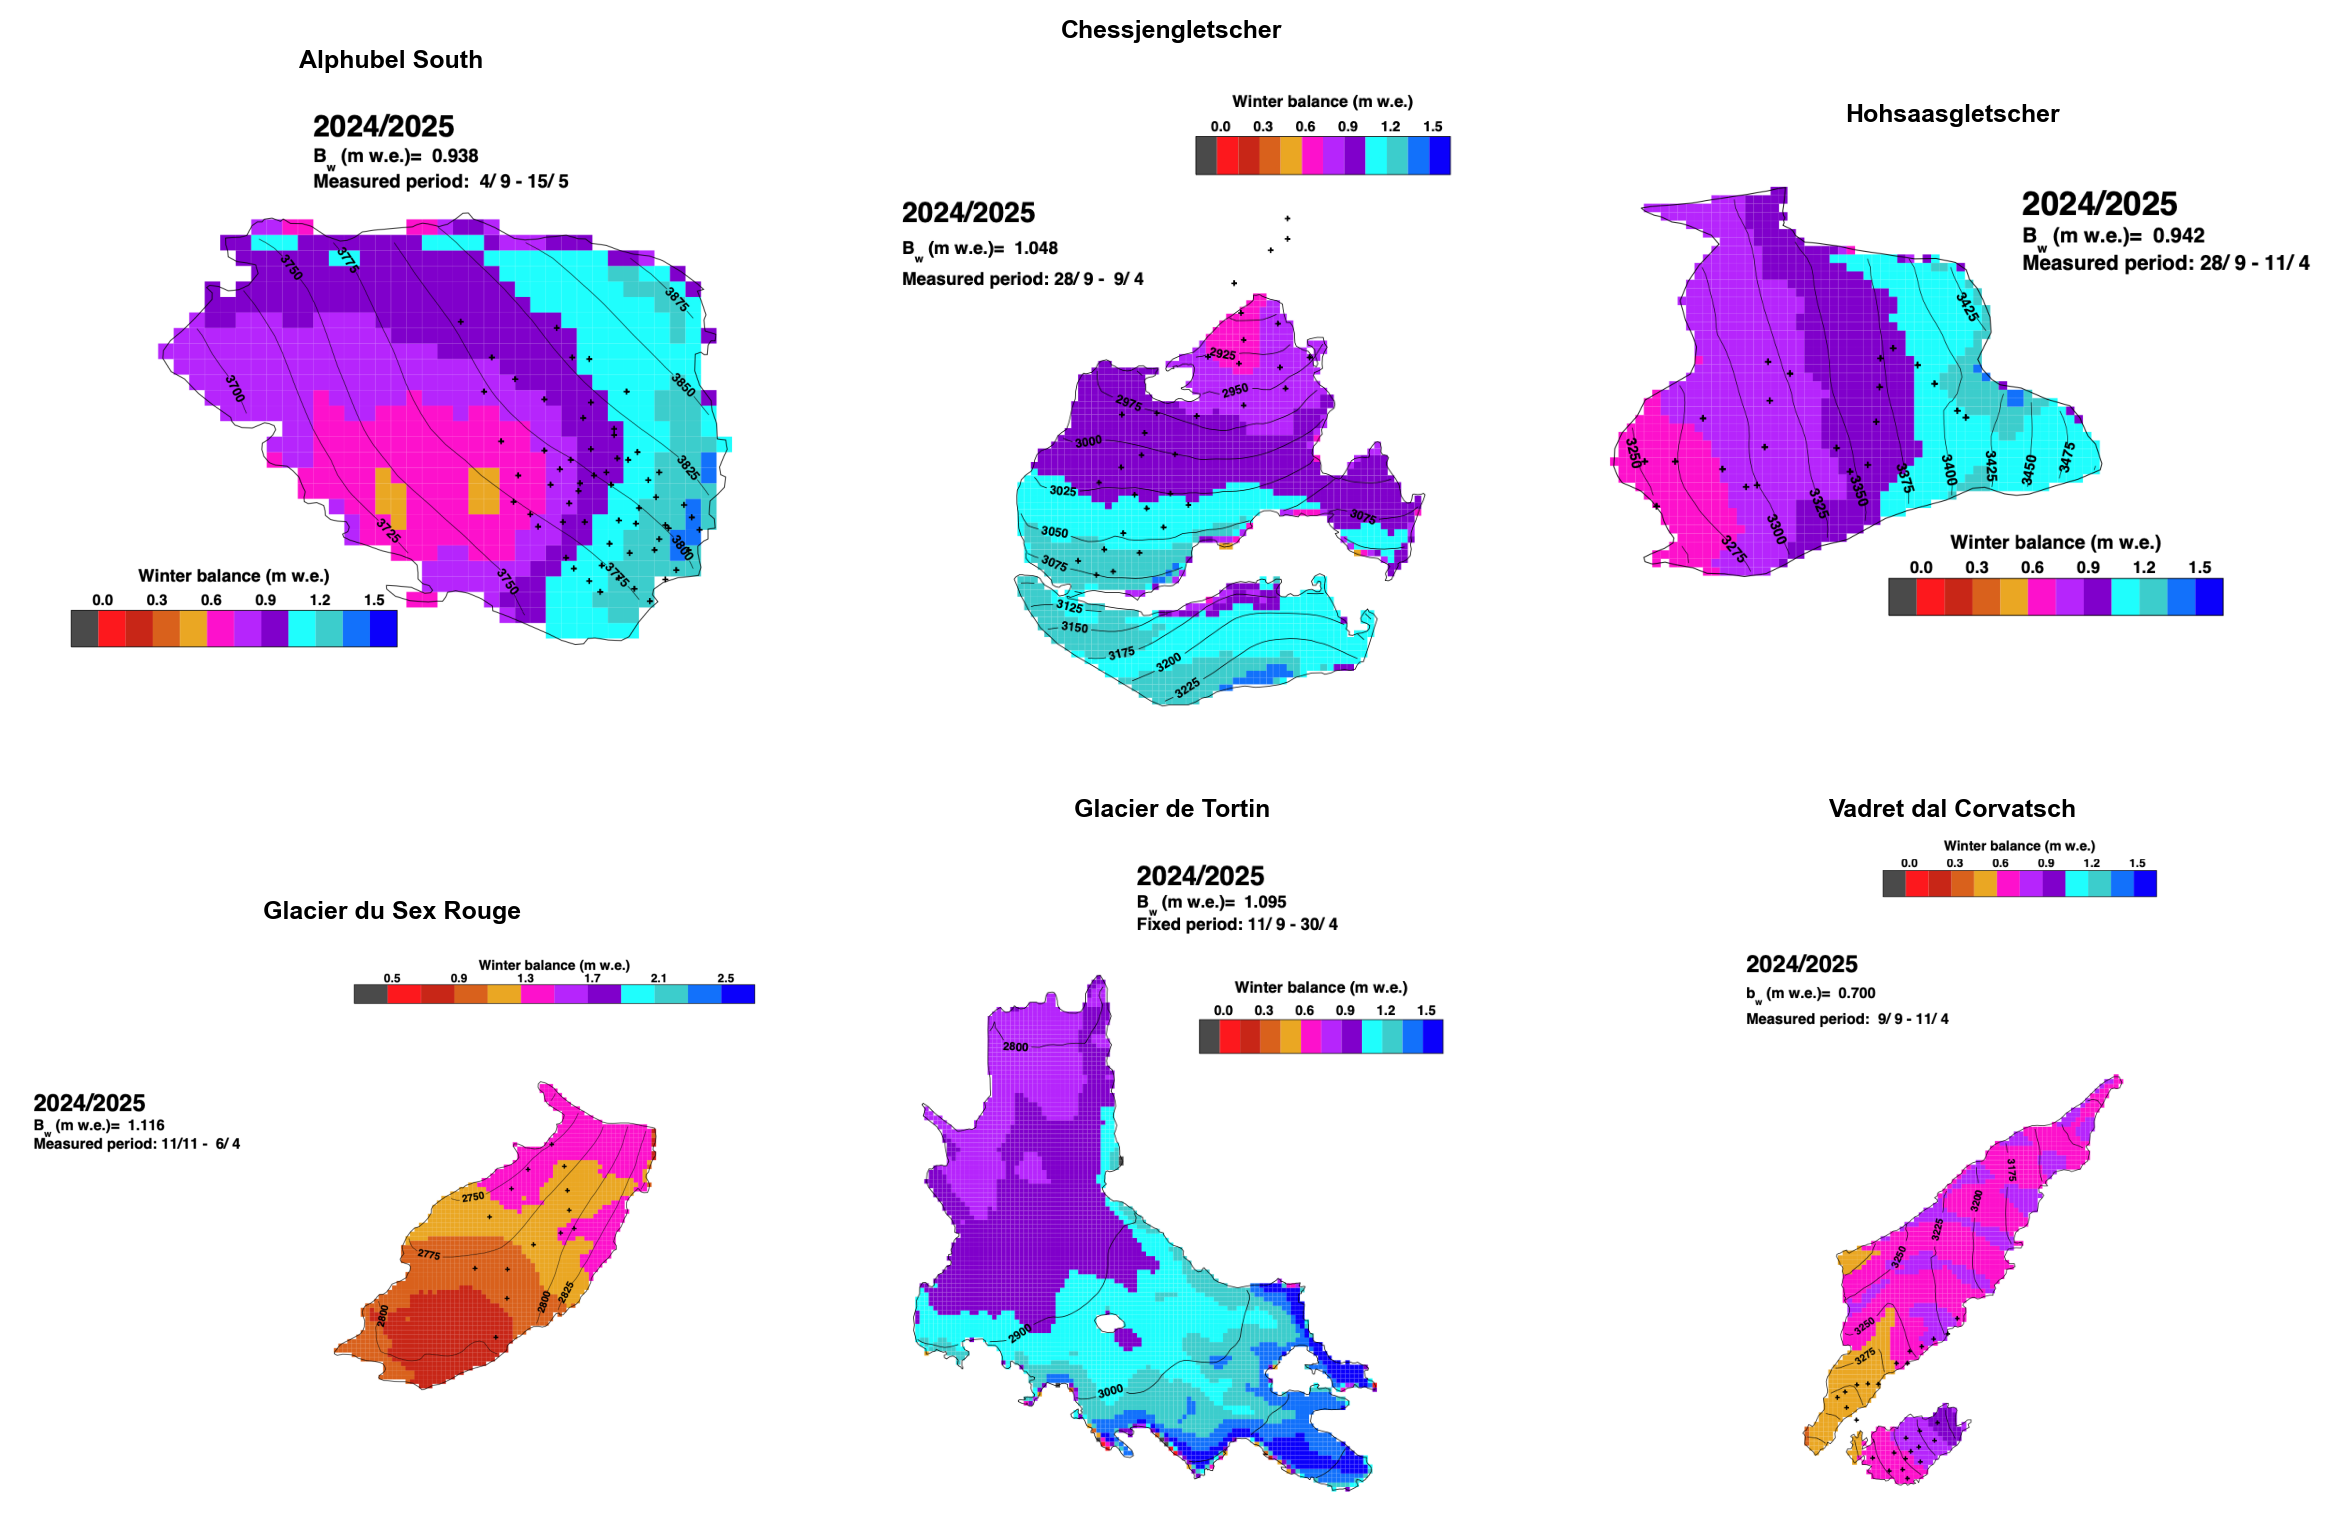

In [3]:
# Map each file index (from the list above) to the glacier label.
# Adjust the indices once you have confirmed which screenshot = which glacier.
glamos_files = {
    'Alphubel South':          all_files[0],
    'Chessjengletscher':       all_files[1],
    'Hohsaasgletscher':        all_files[2],
    'Glacier du Sex Rouge':    all_files[3],
    'Glacier de Tortin':       all_files[4],
    'Vadret dal Corvatsch':    all_files[5],
}

# --- plot mosaic ---
fig, axs = plt.subplots(2, 3, figsize=(12, 8), dpi=200)
fig.subplots_adjust(left=0.02, right=0.98, top=0.93, bottom=0.02,
                    wspace=0.05, hspace=0.15)

for ax, (label, fpath) in zip(axs.flat, glamos_files.items()):
    img = mpimg.imread(str(fpath))
    ax.imshow(img)
    ax.set_title(label, fontsize=9, fontweight='bold', pad=4)
    ax.axis('off')

out_path = output_dir + 'glamos_winter_balance_mosaic.pdf'
fig.savefig(out_path, bbox_inches='tight', dpi=200)
print(f'Saved: {out_path}')
plt.show()

---
## Figure 2 — Annual firn area time series (1970–2026)

Reads the `firn_area_annual_{glacier}.csv` files written by `firn_change.pro`
and plots the evolution of firn-covered area for all 6 glaciers.

Saved: /Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/polythermal_swiss_glaciers/products/figures/mass_balance_figures/firn_area_timeseries.pdf


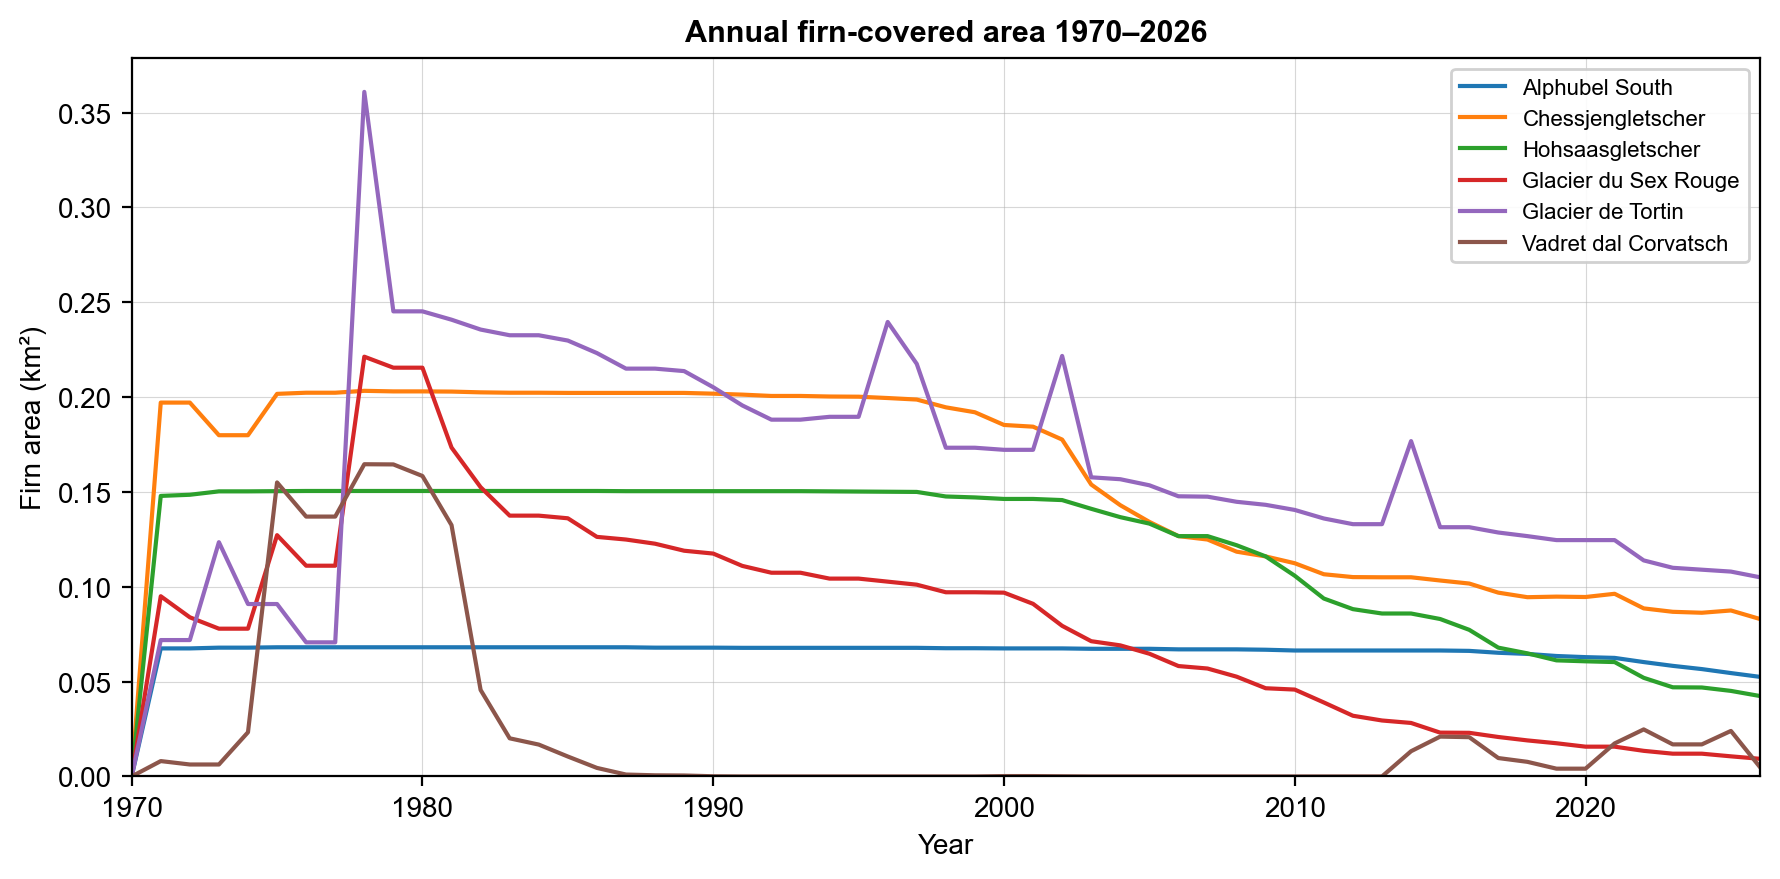

In [4]:
firn_dir = project_root + '/results/firn_grids/'

# glacier keys must match the names used in firn_change.pro
glaciers = [
    {'key': 'alphubel',  'label': 'Alphubel South',       'color': '#1f77b4'},
    {'key': 'felskinn',  'label': 'Chessjengletscher',     'color': '#ff7f0e'},
    {'key': 'hohsaas',   'label': 'Hohsaasgletscher',      'color': '#2ca02c'},
    {'key': 'sexrouge',  'label': 'Glacier du Sex Rouge',  'color': '#d62728'},
    {'key': 'tortin',    'label': 'Glacier de Tortin',     'color': '#9467bd'},
    {'key': 'corvatsch', 'label': 'Vadret dal Corvatsch',  'color': '#8c564b'},
]

CELL_AREA_KM2 = 10 * 10 * 1e-6  # 10 m cell

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=200)

for g in glaciers:
    csv_path = firn_dir + f'firn_area_annual_{g["key"]}.csv'
    if not os.path.exists(csv_path):
        print(f'  NOT FOUND: {csv_path}')
        continue
    df = pd.read_csv(csv_path)
    df['firn_area_km2'] = df['firn_cells'] * CELL_AREA_KM2
    ax.plot(df['year'], df['firn_area_km2'],
            label=g['label'], color=g['color'], linewidth=1.5)

ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Firn area (km²)', fontsize=10)
ax.set_title('Annual firn-covered area 1970–2026', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.9)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.set_xlim(1970, 2026)
ax.set_ylim(bottom=0)

fig.tight_layout()
out_path = output_dir + 'firn_area_timeseries.pdf'
fig.savefig(out_path, bbox_inches='tight', dpi=200)
print(f'Saved: {out_path}')
plt.show()

---
## Figure 3 — Annual firn area: individual panels

Same data as Figure 2 but one panel per glacier, showing also the glacier total area
as a reference (dashed line) so the firn fraction is visually apparent.

Saved: /Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/polythermal_swiss_glaciers/products/figures/mass_balance_figures/firn_area_timeseries_panels.pdf


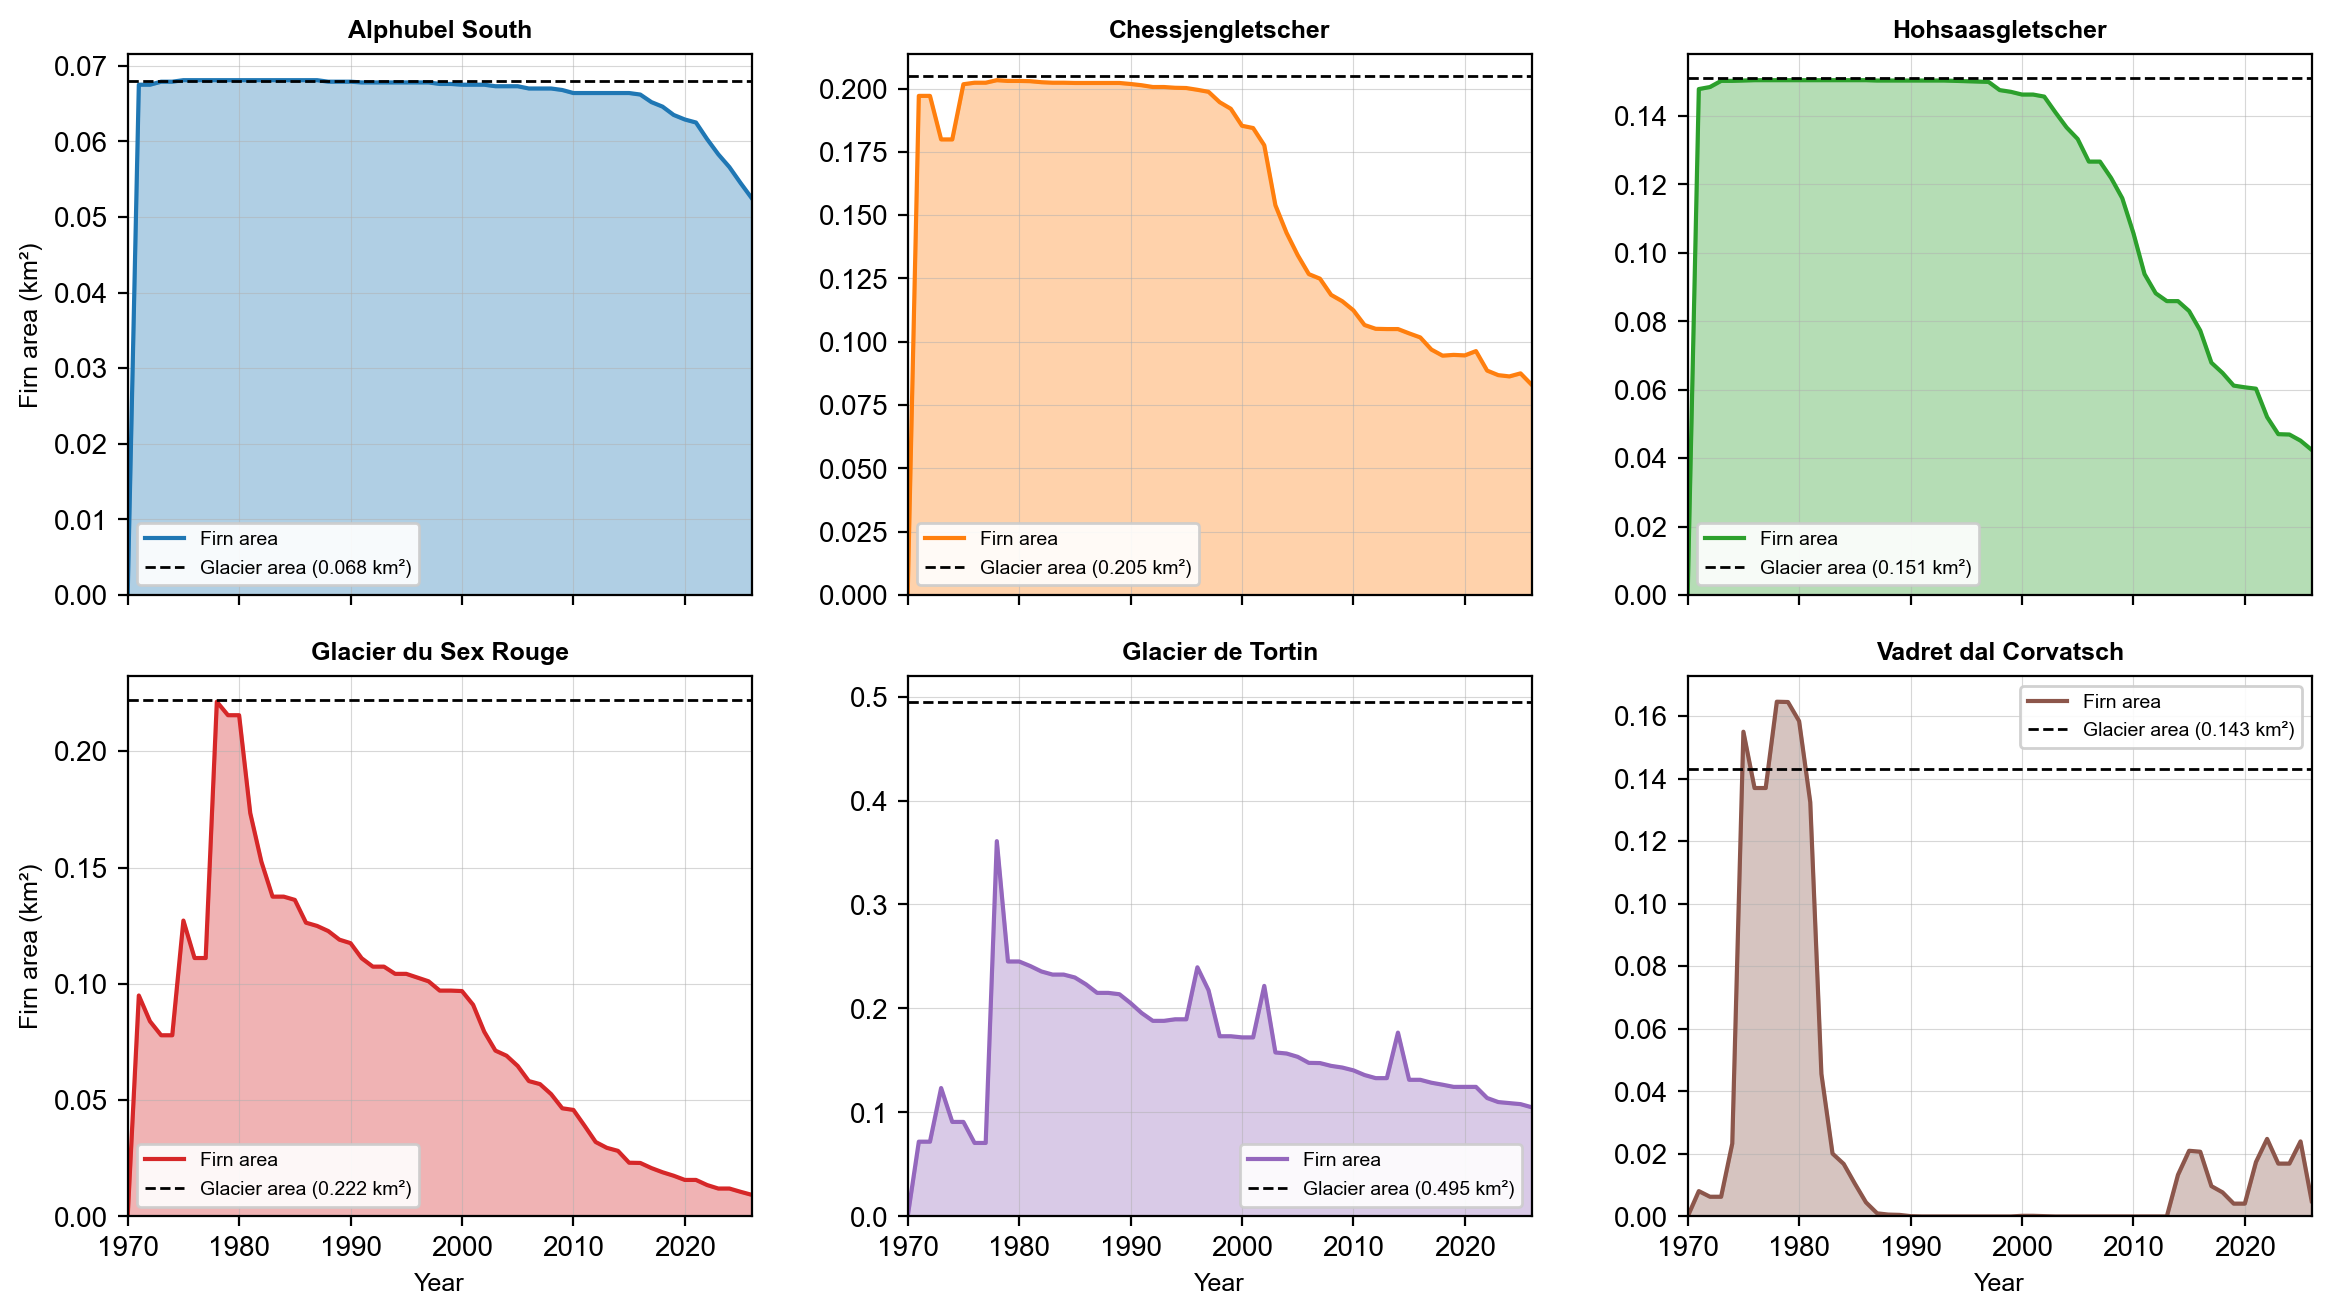

In [5]:
# Total glacier areas from study sites table (km²)
glacier_areas = {
    'alphubel':  0.068,
    'felskinn':  0.205,
    'hohsaas':   0.151,
    'sexrouge':  0.222,
    'tortin':    0.495,
    'corvatsch': 0.143,
}

fig, axs = plt.subplots(2, 3, figsize=(12, 7), dpi=200,
                        sharex=True)
fig.subplots_adjust(left=0.07, right=0.98, top=0.93, bottom=0.10,
                    wspace=0.25, hspace=0.15)

for ax, g in zip(axs.flat, glaciers):
    csv_path = firn_dir + f'firn_area_annual_{g["key"]}.csv'
    if not os.path.exists(csv_path):
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes, fontsize=9)
        ax.set_title(g['label'], fontsize=9, fontweight='bold')
        continue

    df = pd.read_csv(csv_path)
    df['firn_area_km2'] = df['firn_cells'] * CELL_AREA_KM2

    total_area = glacier_areas.get(g['key'])

    ax.fill_between(df['year'], df['firn_area_km2'],
                    alpha=0.35, color=g['color'])
    ax.plot(df['year'], df['firn_area_km2'],
            color=g['color'], linewidth=1.5, label='Firn area')
    if total_area is not None:
        ax.axhline(total_area, color='k', linewidth=1.0,
                   linestyle='--', label=f'Glacier area ({total_area:.3f} km²)')

    ax.set_title(g['label'], fontsize=9, fontweight='bold')
    ax.set_xlim(1970, 2026)
    ax.set_ylim(bottom=0)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    ax.legend(fontsize=7, framealpha=0.9)

for ax in axs[1]:
    ax.set_xlabel('Year', fontsize=9)
for ax in axs[:, 0]:
    ax.set_ylabel('Firn area (km²)', fontsize=9)

out_path = output_dir + 'firn_area_timeseries_panels.pdf'
fig.savefig(out_path, bbox_inches='tight', dpi=200)
print(f'Saved: {out_path}')
plt.show()

---
## Figure 4 — Spatially distributed winter balance (2024/25)

Six-panel map showing the GLAMOS modelled spatially distributed winter balance
for the 2024/25 hydrological year at all six study glaciers.
Data source: `data/glamos/distributed_mass_balance_grids/` (LV95, 10 m resolution).

In [6]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm
from matplotlib.collections import LineCollection
import geopandas as gpd
from affine import Affine
import cmcrameri.cm as cmc

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import src.gpr_processing as gpr
import src.gpr_plotting as gprp
from src.geodata_processing import read_xyzn_to_gdf

MB_DIR    = project_root + '/data/glamos/distributed_mass_balance_grids/'
PT_WINTER = '/Volumes/jabeer/glazioarch/GlacioBaseData/MassBalance/point/winter/'
PT_ANNUAL = '/Volumes/jabeer/glazioarch/GlacioBaseData/MassBalance/point/annual/'
xyzn_dir  = project_root + '/data/raw/sgi_2022/xyzn_lv95/'
bh_csv    = (project_root.replace('projects/polythermal_swiss_glaciers', '')
             + 'data/fieldwork_data/THERMAP_2024_2025/icetemperature_data'
             '/thermistor_borehole_settings/thermistor_coordinates.csv')
output_dir = project_root + '/products/figures/mass_balance_figures/'
os.makedirs(output_dir, exist_ok=True)

ANNO_FONTSIZE = 12
MAP_BUFFER_M  = 100

glaciers_mb = [
    {'key': 'alphubel',  'label': 'Alphubel (AH)',       'abbr': 'AH',
     'mb_path':    MB_DIR + 'alphubel/2025_ann_fix.grid',
     'pt_key':     'alphubel',
     'xyzn_file':  'SGI_2023_B55-15_lv95.xyzn',
     'bh_ids':     ['AH1G', 'AH2G', 'AH3G', 'AH1TT', 'AH2TT', 'AH3TT'],
     'bh_filter':  True},
    {'key': 'chessjen',  'label': 'Chessjen (CJ)',    'abbr': 'CJ',
     'mb_path':    MB_DIR + 'chessjen/2025_ann_fix.grid',
     'pt_key':     'felskinn',
     'xyzn_file':  'SGI_2023_B53-14_lv95.xyzn',
     'bh_ids':     ['CJ1G', 'CJ2G', 'CJ1TT', 'CJ2TT', 'CJ3TT', 'CJ4TT'],
     'bh_filter':  False},
    {'key': 'hohsaas',   'label': 'Hohsaas (HS)',     'abbr': 'HS',
     'mb_path':    MB_DIR + 'hohsaas/2025_ann_fix.grid',
     'pt_key':     'hohsaas',
     'xyzn_file':  'SGI_2023_B51-13_lv95.xyzn',
     'bh_ids':     ['HS1G', 'HS2G', 'HS3G', 'HS1TT', 'HS2TT', 'HS3TT'],
     'bh_filter':  True},
    {'key': 'sex_rouge', 'label': 'Sex Rouge (SR)', 'abbr': 'SR',
     'mb_path':    MB_DIR + 'sex_rouge/2025_ann_fix.grid',
     'pt_key':     'sexrouge',
     'xyzn_file':  'SGI_2023_B16-01_lv95.xyzn',
     'bh_ids':     ['SR1TT', 'SR2TT'],
     'bh_filter':  True},
    {'key': 'tortin',    'label': 'Tortin (GT)',    'abbr': 'GT',
     'mb_path':    MB_DIR + 'tortin/2025_ann_fix.grid',
     'pt_key':     'tortin',
     'xyzn_file':  'SGI_2023_B75-12_lv95.xyzn',
     'bh_ids':     ['GT1TT', 'GT2TT'],
     'bh_filter':  True},
    {'key': 'corvatsch', 'label': 'Corvatsch (CV)', 'abbr': 'CV',
     'mb_path':    MB_DIR + 'corvatsch/2025_ann_fix.grid',
     'pt_key':     'corvatsch',
     'xyzn_file':  'SGI_2022_E23-18_lv95.xyzn',
     'bh_ids':     ['CV1TT', 'CV2TT'],
     'bh_filter':  True},
]

def read_arc_grid(path):
    with open(path) as f:
        ncols     = int(float(f.readline().split()[1]))
        nrows     = int(float(f.readline().split()[1]))
        xllcorner = float(f.readline().split()[1])
        yllcorner = float(f.readline().split()[1])
        cellsize  = float(f.readline().split()[1])
        nodata    = float(f.readline().split()[1])
        data = np.array(f.read().split(), dtype=np.float32).reshape(nrows, ncols)
    data[data == nodata] = np.nan
    if xllcorner < 1_000_000:
        xllcorner += 2_000_000
        yllcorner += 1_000_000
    transform = Affine(cellsize, 0, xllcorner,
                       0, -cellsize, yllcorner + nrows * cellsize)
    valid = ~np.isnan(data)
    valid_rows = np.where(np.any(valid, axis=1))[0]
    valid_cols = np.where(np.any(valid, axis=0))[0]
    north = yllcorner + nrows * cellsize
    xmin = xllcorner + valid_cols[0]  * cellsize
    xmax = xllcorner + (valid_cols[-1] + 1) * cellsize
    ymax = north     - valid_rows[0]  * cellsize
    ymin = north     - (valid_rows[-1] + 1) * cellsize
    return data, transform, (xmin, ymin, xmax, ymax)

def make_square_bbox(xmin, ymin, xmax, ymax, buffer=0):
    cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
    half = max(xmax - xmin, ymax - ymin) / 2 + buffer
    return (cx - half, cy - half, cx + half, cy + half)

def read_mb_points(filepath, year=2025):
    """Read GLAMOS point mass balance file (LV03 → LV95), filter for balance year ending `year`."""
    xs, ys = [], []
    if not os.path.exists(filepath):
        return np.array([]), np.array([])
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) < 10:
                continue
            if not parts[3].startswith(str(year)):
                continue
            try:
                x = float(parts[7])
                y = float(parts[8])
            except (ValueError, IndexError):
                continue
            if not (450_000 < x < 900_000 and 65_000 < y < 300_000):
                continue
            xs.append(x + 2_000_000)
            ys.append(y + 1_000_000)
    return np.array(xs), np.array(ys)

empty_gdf = gpd.GeoDataFrame(
    {'profile': [], 'geometry': gpd.GeoSeries([], crs='EPSG:2056')},
    geometry='geometry', crs='EPSG:2056')

for g in glaciers_mb:
    g['mb_data'], g['tfm'], g['bbox'] = read_arc_grid(g['mb_path'])
    g['bbox_map'] = make_square_bbox(*g['bbox'], MAP_BUFFER_M)
    g['winter_pts'] = read_mb_points(PT_WINTER + f"{g['pt_key']}_winter.dat")
    g['annual_pts'] = read_mb_points(PT_ANNUAL + f"{g['pt_key']}_annual.dat")
    xyzn_path = os.path.join(xyzn_dir, g['xyzn_file'])
    g['outline'] = read_xyzn_to_gdf(xyzn_path) if os.path.exists(xyzn_path) else None
    if g['bh_ids'] and os.path.exists(bh_csv):
        bh, _ = gpr.load_borehole_positions(bh_csv, keep_names=g['bh_ids'])
    else:
        bh = empty_gdf
    g['boreholes'] = bh
    valid = g['mb_data'][~np.isnan(g['mb_data'])]
    print(f"{g['label']:22s}  Ba={np.mean(valid):.2f} m w.e.  "
          f"winter_pts={len(g['winter_pts'][0]):2d}  annual_pts={len(g['annual_pts'][0]):2d}  "
          f"outline={'ok' if g['outline'] is not None else 'MISSING'}  bh={len(bh)}")


Alphubel (AH)           Ba=-0.40 m w.e.  winter_pts=60  annual_pts= 2  outline=ok  bh=6
Chessjen (CJ)           Ba=-0.76 m w.e.  winter_pts=32  annual_pts= 2  outline=ok  bh=6
Hohsaas (HS)            Ba=-1.16 m w.e.  winter_pts=22  annual_pts= 2  outline=ok  bh=5
Sex Rouge (SR)          Ba=-2.72 m w.e.  winter_pts=14  annual_pts= 5  outline=ok  bh=2
Tortin (GT)             Ba=-1.72 m w.e.  winter_pts= 3  annual_pts= 7  outline=ok  bh=2
Corvatsch (CV)          Ba=-1.30 m w.e.  winter_pts=27  annual_pts= 2  outline=ok  bh=2


Saved: /Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/polythermal_swiss_glaciers/products/figures/mass_balance_figures/annual_balance_distribution.pdf


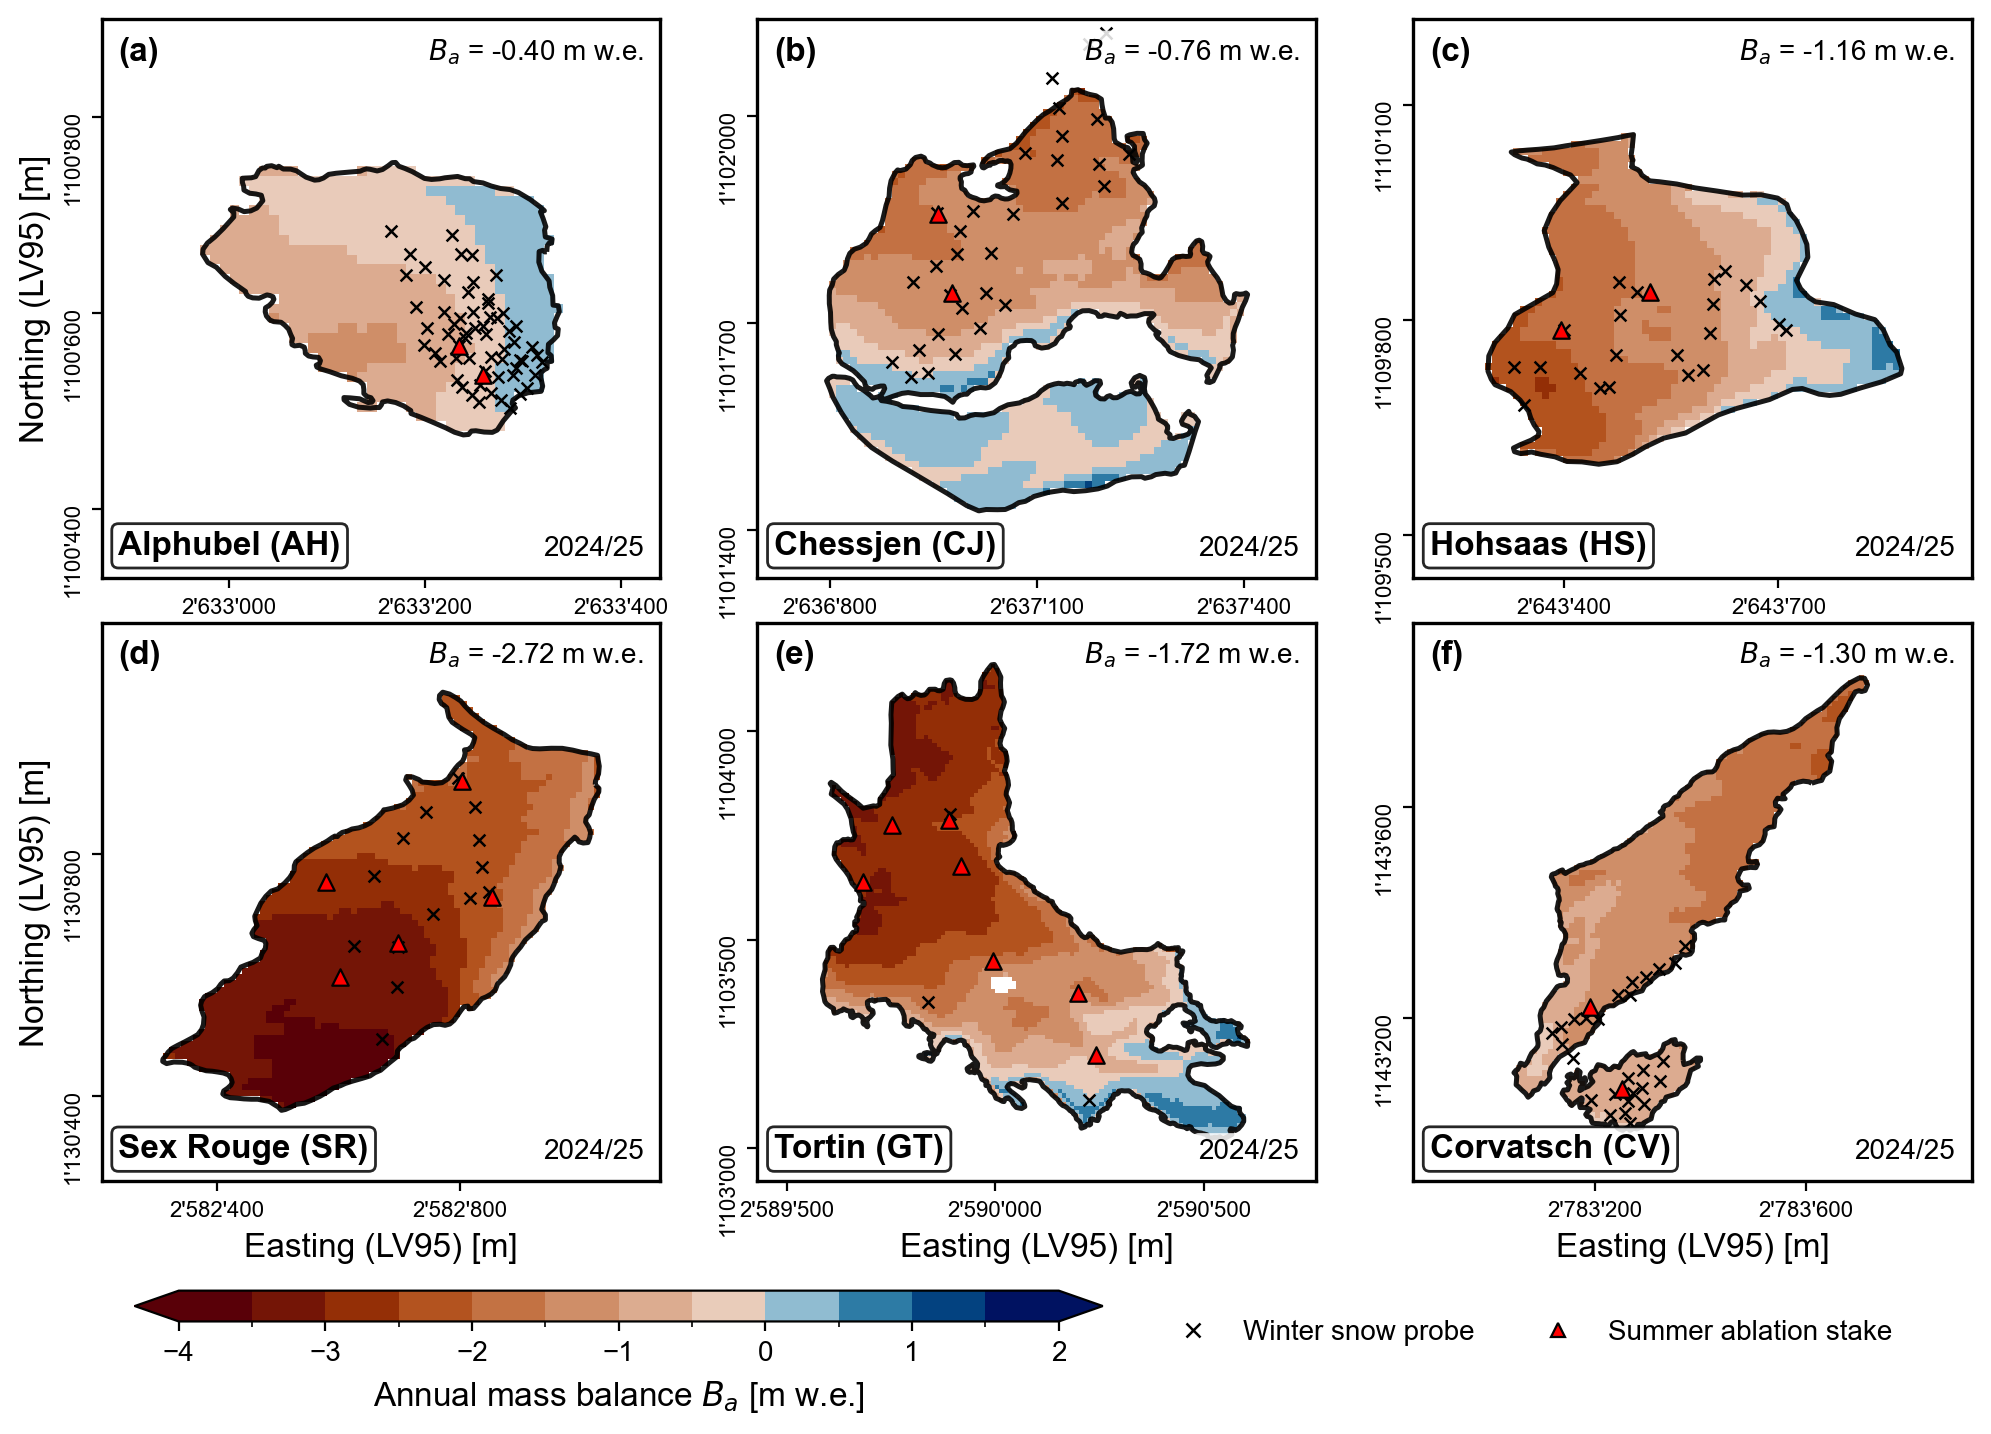

In [7]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from shapely.geometry import Polygon, MultiPolygon, GeometryCollection, Point, box as shapely_box
from shapely.prepared import prep
from matplotlib.lines import Line2D

levels_mb = np.arange(-4.0, 2.0 + 0.01, 0.5)
n_neg = int(np.sum(levels_mb < 0))   # bins below 0
n_pos = int(np.sum(levels_mb > 0))   # bins above 0
# Sample lower half of vik_r for negatives, upper half for positives,
# so that the colormap neutral falls exactly at the 0 boundary.
neg_colors = cmc.vik_r(np.linspace(0, 0.5, n_neg, endpoint=False))
pos_colors = cmc.vik_r(np.linspace(0.5, 1.0, n_pos + 1)[1:])
cmap_mb = ListedColormap(np.vstack([neg_colors, pos_colors]))
norm_mb   = BoundaryNorm(levels_mb, cmap_mb.N)

SP  = dict(left=0.11, right=0.99, top=0.97, bottom=0.14, wspace=0.05, hspace=0.08)
fmt = mticker.FuncFormatter(lambda v, _: f"{int(v):,}".replace(',', "'"))

fig, axs = plt.subplots(2, 3, figsize=(11, 7), dpi=200)
fig.subplots_adjust(**SP)

def draw_outline(ax, geoms_iter, color='black', lw=1.8, alpha=0.9, zorder=11):
    segs = []
    for geom in geoms_iter:
        if geom is None or geom.is_empty:
            continue
        parts_raw = list(geom.geoms) if isinstance(geom, (GeometryCollection, MultiPolygon)) else [geom]
        for part in parts_raw:
            if isinstance(part, Polygon) and not part.is_empty:
                segs.append(list(part.exterior.coords))
            elif isinstance(part, MultiPolygon):
                for p in part.geoms:
                    if not p.is_empty:
                        segs.append(list(p.exterior.coords))
    if segs:
        ax.add_collection(LineCollection(segs, colors=color, linewidths=lw,
                                         alpha=alpha, zorder=zorder))

def prepare_outline(gdf_raw, mb_bbox, panel_bbox, bh_points=None, bh_filter=True):
    mb_box  = shapely_box(*mb_bbox)
    pan_box = shapely_box(*panel_bbox)
    result  = []
    for geom in gdf_raw.geometry:
        if geom is None or geom.is_empty:
            continue
        if not geom.is_valid:
            try:
                geom = geom.buffer(0)
            except Exception:
                continue
        try:
            ovlp_area = geom.intersection(mb_box).area
        except Exception:
            ovlp_area = 0
        if ovlp_area < 5000:
            continue
        if bh_filter and bh_points:
            if not any(geom.contains(pt) for pt in bh_points):
                continue
        try:
            clipped = geom.intersection(pan_box)
        except Exception:
            clipped = geom
        if clipped is None or clipped.is_empty:
            continue
        if isinstance(clipped, (Polygon, MultiPolygon)) and clipped.area < 1.0:
            continue
        result.append(clipped)
    return result

def explode_outline_geoms(geoms):
    parts = []
    for geom in geoms:
        if geom is None or geom.is_empty:
            continue
        if isinstance(geom, MultiPolygon):
            parts.extend([part for part in geom.geoms if not part.is_empty])
        elif isinstance(geom, GeometryCollection):
            for part in geom.geoms:
                if isinstance(part, MultiPolygon):
                    parts.extend([subpart for subpart in part.geoms if not subpart.is_empty])
                elif isinstance(part, Polygon) and not part.is_empty:
                    parts.append(part)
        else:
            parts.append(geom)
    return parts

def keep_supported_outline_geoms(geoms, mb_data, transform):
    valid_rows, valid_cols = np.where(~np.isnan(mb_data))
    if len(valid_rows) == 0:
        return geoms

    valid_xs, valid_ys = transform * (valid_cols + 0.5, valid_rows + 0.5)
    support_scores = []

    for geom in geoms:
        if geom is None or geom.is_empty:
            continue
        prepared_geom = prep(geom)
        score = 0

        for x, y in zip(valid_xs, valid_ys):
            if prepared_geom.contains(Point(float(x), float(y))):
                score += 1

        support_scores.append((score, geom))

    if not support_scores:
        return geoms

    supported = [geom for score, geom in support_scores if score > 0]
    if supported:
        return supported

    return [max(support_scores, key=lambda item: item[0])[1]]

for i, (g, ax) in enumerate(zip(glaciers_mb, axs.flat)):
    x0, y0, x1, y1 = g['bbox_map']

    ax.set_facecolor('white')

    gprp.imshow_grid(ax, g['mb_data'], g['tfm'],
                     cmap=cmap_mb, alpha=1.0, norm=norm_mb, zorder=5)

    if g['outline'] is not None:
        bh_pts = [Point(row.geometry.x, row.geometry.y)
                  for _, row in g['boreholes'].iterrows()]
        geoms = prepare_outline(g['outline'], g['bbox'], g['bbox_map'],
                                bh_points=bh_pts, bh_filter=g['bh_filter'])
        geoms = keep_supported_outline_geoms(explode_outline_geoms(geoms),
                                             g['mb_data'], g['tfm'])
        draw_outline(ax, geoms)

    # winter snow probe positions
    wx, wy = g['winter_pts']
    if len(wx):
        ax.scatter(wx, wy, s=18, marker='x', color='black',
                   linewidths=0.9, zorder=20)

    # annual ablation stake positions
    ax_x, ax_y = g['annual_pts']
    if len(ax_x):
        ax.scatter(ax_x, ax_y, s=35, marker='^', color='red',
                   edgecolors='black', linewidths=0.8, zorder=20)

    ax.text(0.03, 0.97, f'({chr(ord("a") + i)})', transform=ax.transAxes,
            ha='left', va='top', fontsize=ANNO_FONTSIZE, fontweight='bold', zorder=25,
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=1.0))

    valid   = g['mb_data'][~np.isnan(g['mb_data'])]
    ba_mean = float(np.mean(valid))
    ax.text(0.97, 0.97, f'$B_a$ = {ba_mean:.2f} m w.e.', transform=ax.transAxes,
            ha='right', va='top', fontsize=ANNO_FONTSIZE - 2, zorder=25,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.85))

    ax.text(0.03, 0.03, g['label'], transform=ax.transAxes,
            ha='left', va='bottom', fontsize=ANNO_FONTSIZE, fontweight='bold', zorder=25,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='black', alpha=0.85))

    ax.text(0.97, 0.03, '2024/25', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=ANNO_FONTSIZE - 2, zorder=25,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.85))

    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_aspect('equal', adjustable='box')
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=3, prune=None))
    ax.xaxis.set_major_formatter(fmt)
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.set_xlabel('Easting (LV95) [m]' if i // 3 == 1 else '', fontsize=ANNO_FONTSIZE)

    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=3, prune=None))
    ax.yaxis.set_major_formatter(fmt)
    ax.tick_params(axis='y', rotation=90, labelsize=8)
    ax.set_ylabel('Northing (LV95) [m]' if i % 3 == 0 else '', fontsize=ANNO_FONTSIZE)

# colorbar — left portion of bottom strip
bottom_shift = 0.03
cax_left = SP['left'] + bottom_shift
cax_w    = 0.44
cax = fig.add_axes([cax_left, 0.04, cax_w, 0.022])
cb  = fig.colorbar(plt.cm.ScalarMappable(norm=norm_mb, cmap=cmap_mb),
                   cax=cax, orientation='horizontal', extend='both')
cb.set_label('Annual mass balance $B_a$ [m w.e.]', fontsize=ANNO_FONTSIZE)
cb.ax.tick_params(labelsize=ANNO_FONTSIZE - 2)

# legend — right portion of bottom strip
legend_handles = [
    Line2D([0], [0], marker='x', color='black', linestyle='none',
           markersize=5, markeredgewidth=0.9, label='Winter snow probe'),
    Line2D([0], [0], marker='^', color='red', linestyle='none',
           markersize=5, markeredgewidth=0.8,
           markerfacecolor='red', markeredgecolor='black', label='Summer ablation stake'),
]
fig.legend(handles=legend_handles, loc='lower right', ncol=2,
           fontsize=ANNO_FONTSIZE - 2, framealpha=0.9, frameon=False,
           bbox_to_anchor=(0.92 + bottom_shift, 0.005))

out_path = output_dir + 'annual_balance_distribution.pdf'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()
